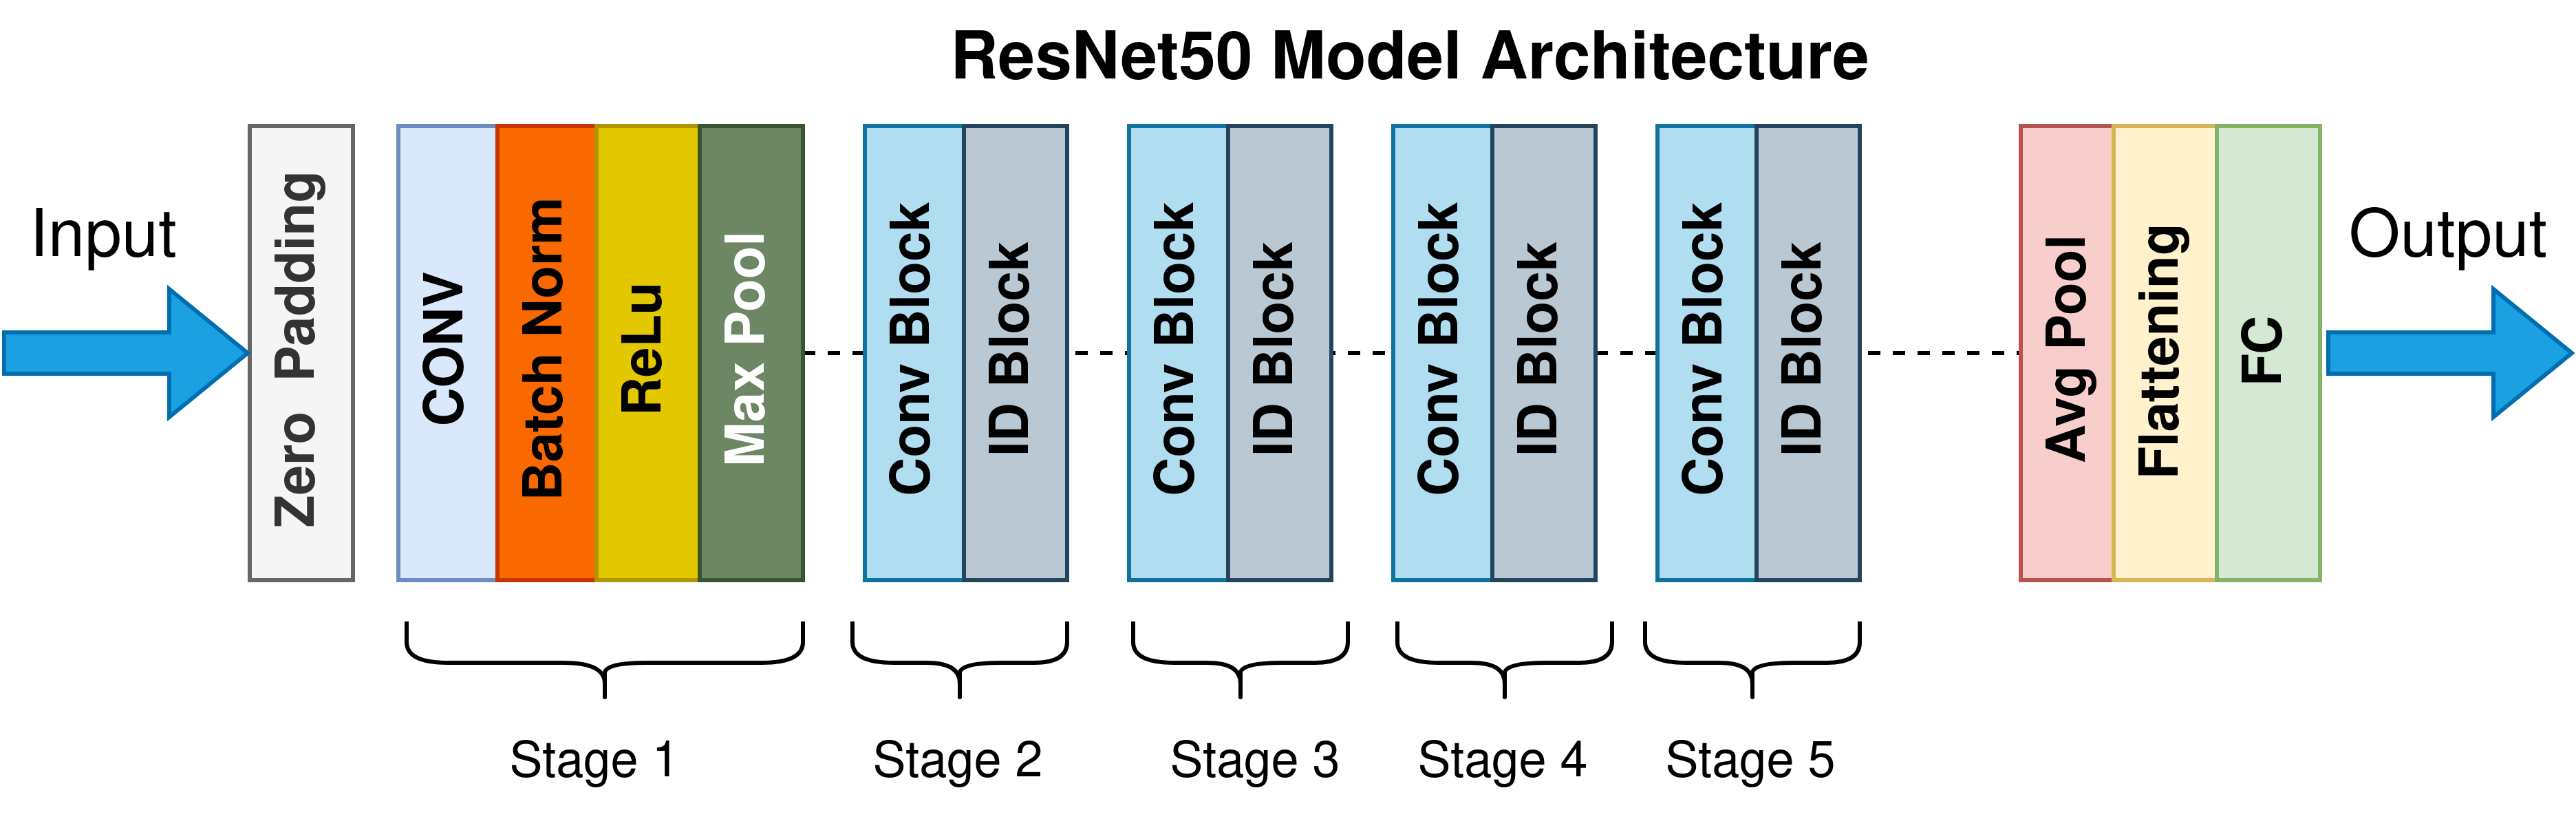

https://github.com/keras-team/keras/blob/v3.3.3/keras/src/applications/resnet.py#L48

In [36]:
import os
import shutil
import itertools
from glob import glob
from pathlib import Path
import json
import platform

In [37]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import keras
import tensorflow as tf
from keras.models import Model
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory, get_file

import kagglehub

In [38]:
SEED = 42
keras.utils.set_random_seed(SEED)
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
DATASET_ID = "andrewmvd/lung-and-colon-cancer-histopathological-images"

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [39]:
OUTPUT_DIR = Path("/content/exp-2-outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [40]:
assert TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION == 1.0
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1'}


In [41]:
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.


In [42]:
colon_directories = list(dataset_root.rglob("colon_image_sets"))

if len(colon_directories) != 1:
    raise RuntimeError(
        f"Expected exactly one colon_image_sets directory, found {colon_directories}"
    )

colon_root = colon_directories[0]
print("Dataset root:", dataset_root)
print("Colon root:", colon_root)

Dataset root: /kaggle/input/lung-and-colon-cancer-histopathological-images
Colon root: /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets


## 3. Build the binary index

The positive class is adenocarcinoma (`1`); benign tissue is class `0`. Stable relative paths make the manifest portable across Colab runtimes.

In [43]:
CLASS_MAPPING = {
    "colon_n": {"label": 0, "class_name": "benign"},
    "colon_aca": {"label": 1, "class_name": "adenocarcinoma"},
}
SUPPORTED_SUFFIXES = {".jpg", ".jpeg", ".png"}
records = []

for folder_name, class_info in CLASS_MAPPING.items():
    class_directory = colon_root / folder_name
    if not class_directory.is_dir():
        raise FileNotFoundError(f"Missing expected class directory: {class_directory}")

    image_paths = sorted(
        path for path in class_directory.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_SUFFIXES
    )
    for image_path in image_paths:
        records.append({
            "relative_path": image_path.relative_to(colon_root).as_posix(),
            "filepath": str(image_path),
            "label": class_info["label"],
            "class_name": class_info["class_name"],
        })

image_index = pd.DataFrame.from_records(records).sort_values(
    ["label", "relative_path"]
).reset_index(drop=True)

expected_counts = {"benign": 5000, "adenocarcinoma": 5000}
actual_counts = image_index["class_name"].value_counts().to_dict()
assert actual_counts == expected_counts, (actual_counts, expected_counts)
assert len(image_index) == 10_000
assert image_index["relative_path"].is_unique
display(image_index.head())
display(image_index["class_name"].value_counts().sort_index())


,relative_path,filepath,label,class_name
0,colon_n/colonn1.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
1,colon_n/colonn10.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
2,colon_n/colonn100.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
3,colon_n/colonn1000.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
4,colon_n/colonn1001.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign


,count
class_name,
adenocarcinoma,5000
benign,5000


## 4. Create train, validation, and test partitions

The test partition is isolated before model training. Validation is used for early stopping and model selection; test is evaluated only after the complete training procedure is fixed.


In [44]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    image_index,
    test_size=VALIDATION_FRACTION + TEST_FRACTION,
    stratify=image_index["label"],
    random_state=SEED,
)

relative_test_fraction = TEST_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION)
validation_df, test_df = train_test_split(
    temporary_df,
    test_size=relative_test_fraction,
    stratify=temporary_df["label"],
    random_state=SEED,
)

partitions = {
    "train": train_df.reset_index(drop=True),
    "validation": validation_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}

for split_name, frame in partitions.items():
    print(f"{split_name}: {len(frame):,}")
    print(frame["class_name"].value_counts().sort_index().to_dict())


train: 7,000
{'adenocarcinoma': 3500, 'benign': 3500}
validation: 1,500
{'adenocarcinoma': 750, 'benign': 750}
test: 1,500
{'adenocarcinoma': 750, 'benign': 750}


## 5. Validate split integrity

These assertions prevent accidental overlap, missing images, duplicated assignments, and class imbalance.


In [45]:
expected_sizes = {"train": 7000, "validation": 1500, "test": 1500}
expected_per_class = {
    "train": {"adenocarcinoma": 3500, "benign": 3500},
    "validation": {"adenocarcinoma": 750, "benign": 750},
    "test": {"adenocarcinoma": 750, "benign": 750},
}

split_paths = {}
for split_name, frame in partitions.items():
    assert len(frame) == expected_sizes[split_name]
    assert frame["class_name"].value_counts().to_dict() == expected_per_class[split_name]
    assert frame["relative_path"].is_unique
    assert frame["filepath"].map(lambda value: Path(value).is_file()).all()
    split_paths[split_name] = set(frame["relative_path"])

assert split_paths["train"].isdisjoint(split_paths["validation"])
assert split_paths["train"].isdisjoint(split_paths["test"])
assert split_paths["validation"].isdisjoint(split_paths["test"])
assert set.union(*split_paths.values()) == set(image_index["relative_path"])
print("Split integrity checks passed.")


Split integrity checks passed.


## 6. Export the reusable split manifest

Commit the compact manifest with the experiment evidence. Do not commit the downloaded dataset. The later MobileNetV2 notebook must load this manifest instead of creating another random split.


In [46]:
manifest_frames = []
for split_name, frame in partitions.items():
    exported = frame[["relative_path", "label", "class_name"]].copy()
    exported.insert(0, "split", split_name)
    manifest_frames.append(exported)

split_manifest = pd.concat(manifest_frames, ignore_index=True).sort_values(
    ["split", "label", "relative_path"]
).reset_index(drop=True)
manifest_path = OUTPUT_DIR / "split_manifest.csv"
split_manifest.to_csv(manifest_path, index=False)

split_metadata = {
    "dataset_id": DATASET_ID,
    "task": "binary_colon_classification",
    "seed": SEED,
    "fractions": {
        "train": TRAIN_FRACTION,
        "validation": VALIDATION_FRACTION,
        "test": TEST_FRACTION,
    },
    "class_mapping": {"benign": 0, "adenocarcinoma": 1},
    "counts": {name: len(frame) for name, frame in partitions.items()},
}
metadata_path = OUTPUT_DIR / "split_metadata.json"
metadata_path.write_text(json.dumps(split_metadata, indent=2), encoding="utf-8")

print("Saved:", manifest_path)
print("Saved:", metadata_path)
display(split_manifest.groupby(["split", "class_name"]).size().unstack())


Saved: /content/exp-2-outputs/split_manifest.csv
Saved: /content/exp-2-outputs/split_metadata.json


class_name,adenocarcinoma,benign
split,,
test,750,750
train,3500,3500
validation,750,750


## 7. Download split evidence from Colab

Run this cell after all checks pass, then copy both files into `experiments/exp-2/outputs/` locally.


In [47]:
from google.colab import files

files.download(str(manifest_path))
files.download(str(metadata_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
IMG_SIZE = 224

# Medias por canal del conjunto ImageNet, en orden BGR.
IMAGENET_BGR_MEANS = np.array([103.939, 116.779, 123.68], dtype="float32")


def preprocess_resnet50(image):
    """Replica el preprocesamiento con el que se entrenaron los pesos de ResNet50.

    Los pesos publicados provienen de un entrenamiento en Caffe, donde la entrada
    se ordena en BGR y se centra restando la media de cada canal, sin reescalar a
    [0, 1] ni a [-1, 1]. Aplicar una normalizacion distinta no produce error en
    ejecucion, pero desplaza la entrada respecto a la distribucion que vieron los
    filtros durante el preentrenamiento y degrada las representaciones extraidas.
    """
    image = np.asarray(image, dtype="float32")
    image = image[..., ::-1]                # RGB -> BGR
    return image - IMAGENET_BGR_MEANS       # centrado por canal


train_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_resnet50,
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="reflect"
)

eval_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_resnet50
)

# Verificacion: un pixel rojo puro (255, 0, 0) debe quedar como
# (0 - 103.939, 0 - 116.779, 255 - 123.68) al reordenarse a BGR.
_probe = preprocess_resnet50(np.array([[[255.0, 0.0, 0.0]]], dtype="float32"))
assert np.allclose(_probe[0, 0], [-103.939, -116.779, 131.32], atol=1e-3), _probe
assert _probe.dtype == np.float32
print("Normalizacion propia verificada:", _probe[0, 0])

Normalizacion propia verificada: [-103.939 -116.779  131.32 ]


In [49]:
# Continue from the verified 70/15/15 binary split above.
# String labels make the generator's class mapping explicit.
generator_arguments = {
    "x_col": "filepath",
    "y_col": "class_name",
    "target_size": (IMG_SIZE, IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "class_mode": "binary",
    "classes": ["benign", "adenocarcinoma"],
}

train_resnet = train_gen_resnet.flow_from_dataframe(
    train_df, shuffle=True, seed=SEED, **generator_arguments
)
validation_resnet = eval_gen_resnet.flow_from_dataframe(
    validation_df, shuffle=False, **generator_arguments
)
test_resnet = eval_gen_resnet.flow_from_dataframe(
    test_df, shuffle=False, **generator_arguments
)

expected_class_indices = {"benign": 0, "adenocarcinoma": 1}
assert train_resnet.class_indices == expected_class_indices
assert validation_resnet.class_indices == expected_class_indices
assert test_resnet.class_indices == expected_class_indices
assert train_resnet.samples == 7000
assert validation_resnet.samples == 1500
assert test_resnet.samples == 1500

batch_images, batch_labels = next(iter(train_resnet))
assert batch_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert set(np.unique(batch_labels)).issubset({0.0, 1.0})
train_resnet.reset()
print("Generator checks passed.")
print("Class indices:", train_resnet.class_indices)
print("Batch shapes:", batch_images.shape, batch_labels.shape)

batch_signature = (
    tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None,), dtype=tf.float32),
)

def as_tf_dataset(iterator):
    """Wrap a legacy image iterator in the Keras 3-supported tf.data boundary."""
    return tf.data.Dataset.from_generator(
        lambda: iter(iterator), output_signature=batch_signature
    )

train_dataset = as_tf_dataset(train_resnet)
validation_dataset = as_tf_dataset(validation_resnet)
test_dataset = as_tf_dataset(test_resnet)
dataset_images, dataset_labels = next(iter(train_dataset))
assert dataset_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert dataset_labels.shape[0] == dataset_images.shape[0]
train_resnet.reset()
print("tf.data adapter check passed.")

Found 7000 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.
Generator checks passed.
Class indices: {'benign': 0, 'adenocarcinoma': 1}
Batch shapes: (32, 224, 224, 3) (32,)
tf.data adapter check passed.


Imagenes de prueba con una hermana casi identica en entrenamiento:
  similitud >= 0.99: 100.0%
  similitud >= 0.995: 99.3%
  similitud >= 0.999: 80.1%


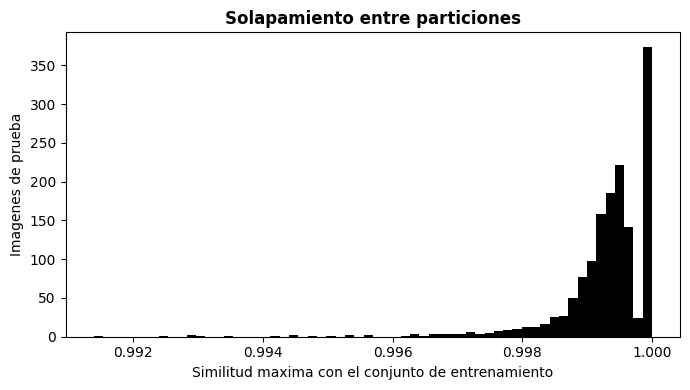

In [69]:
from PIL import Image

def firma_de_color(ruta, bins=32):
    """Descriptor invariante a rotacion y volteo.

    Las imagenes hermanas del dataset son rotaciones y volteos de un mismo corte,
    operaciones que no alteran la distribucion de valores de sus pixeles. El
    histograma de color del centro de la imagen es por tanto casi identico entre
    hermanas y distinto entre cortes de origen diferentes.
    """
    with Image.open(ruta) as archivo:
        archivo.draft("RGB", (256, 256))
        imagen = archivo.convert("RGB").resize((128, 128))
    centro = np.asarray(imagen, dtype=np.uint8)[19:109, 19:109]
    histograma = np.concatenate([
        np.histogram(centro[..., canal], bins=bins, range=(0, 256))[0]
        for canal in range(3)
    ]).astype("float32")
    return histograma / np.linalg.norm(histograma)


firmas = np.stack([firma_de_color(ruta) for ruta in image_index["filepath"]])
posicion = {ruta: i for i, ruta in enumerate(image_index["relative_path"])}
idx_train = np.array([posicion[r] for r in train_df["relative_path"]])
idx_test = np.array([posicion[r] for r in test_df["relative_path"]])

similitud_maxima = (firmas[idx_test] @ firmas[idx_train].T).max(axis=1)

print("Imagenes de prueba con una hermana casi identica en entrenamiento:")
for umbral in (0.99, 0.995, 0.999):
    print(f"  similitud >= {umbral}: {(similitud_maxima >= umbral).mean():.1%}")

plt.figure(figsize=(7, 4))
plt.hist(similitud_maxima, bins=60, color="black")
plt.xlabel("Similitud maxima con el conjunto de entrenamiento")
plt.ylabel("Imagenes de prueba")
plt.title("Solapamiento entre particiones", weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "solapamiento_particiones.png", dpi=160, bbox_inches="tight")
plt.show()

## Anexo: implementación alternativa de los bloques residuales

Implementación propia y autocontenida del cuello de botella residual, escrita
para verificar la comprensión del mecanismo. No se usa en el modelo entrenado.

No reproduce la topología exacta del ResNet50 publicado (convoluciones sin sesgo,
stride en la 3x3 en lugar de la primera 1x1, atajo sin normalización, epsilon por
defecto, y bloques declarados como modelos anidados), y los pesos de ImageNet
solo cargan sobre esa topología. Entrenar el extractor desde cero no es viable
con las imágenes de origen disponibles, por lo que se usó `residual_block_v1`,
fiel al original y compatible con los pesos.

Estos bloques quedan como referencia para entrenar una red residual desde cero
sobre un problema de menor escala.

In [50]:
# No se usa en el modelo entrenado: es incompatible con los pesos de ImageNet.
# Ver la justificacion en el anexo, encima de esta seccion.

def id_block(spatial_size, depth):
  """Bottleneck ID block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    raise ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = x
  shortcut = inputs


  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(3,3), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=depth, kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

In [51]:
# No se usa en el modelo entrenado: es incompatible con los pesos de ImageNet.
# Ver la justificacion en el anexo, encima de esta seccion.

def conv_block(spatial_size, depth):
  """Bottleneck convolutional block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    raise ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = F(x)
  shortcut = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', strides=(2,2))(inputs)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(3,3), padding='same', strides=(2,2), use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

## Implementacion de ResNet50

In [52]:
BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/resnet/"
)

WEIGHTS_HASHES = {
    "resnet50": (
        "2cb95161c43110f7111970584f804107",
        "4d473c1dd8becc155b73f8504c6f6626",
    ),
}

In [53]:
def ResNet(
    stack_fn,
    preact,
    use_bias,
    model_name="resnet",
    weights="imagenet",
    input_shape=None,
    pooling=None,
):
    """Construye el tronco residual y carga los pesos preentrenados.

    La cabeza de clasificacion original de ImageNet no se construye: el modelo se
    utiliza exclusivamente como extractor de caracteristicas, y la cabeza propia
    del problema binario se ensambla despues sobre su salida.

    Args:
        stack_fn: funcion que devuelve el tensor de salida de los bloques apilados.
        preact: preactivacion. True para ResNetV2, False para ResNet y ResNeXt.
        use_bias: sesgo en las convoluciones. True para ResNet y ResNetV2.
        model_name: nombre del modelo, usado para localizar el archivo de pesos.
        weights: "imagenet", None, o la ruta a un archivo de pesos.
        input_shape: forma de la entrada, por ejemplo (224, 224, 3).
        pooling: None, "avg" o "max" sobre el ultimo mapa convolucional.

    Returns:
        Una instancia de Model.
    """
    img_input = keras.layers.Input(shape=input_shape)
    bn_axis = -1

    x = keras.layers.ZeroPadding2D(padding=((3, 3), (3, 3)), name="conv1_pad")(
        img_input
    )
    x = keras.layers.Conv2D(64, 7, strides=2, use_bias=use_bias, name="conv1_conv")(x)

    if not preact:
        x = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name="conv1_bn"
        )(x)
        x = keras.layers.Activation("relu", name="conv1_relu")(x)

    x = keras.layers.ZeroPadding2D(padding=((1, 1), (1, 1)), name="pool1_pad")(x)
    x = keras.layers.MaxPooling2D(3, strides=2, name="pool1_pool")(x)

    x = stack_fn(x)

    if pooling == "avg":
        x = keras.layers.GlobalAveragePooling2D(name="avg_pool")(x)
    elif pooling == "max":
        x = keras.layers.GlobalMaxPooling2D(name="max_pool")(x)

    model = Model(img_input, x, name=model_name)

    if weights == "imagenet":
        if model_name not in WEIGHTS_HASHES:
            raise ValueError(
                f"No hay hash de pesos registrado para el modelo '{model_name}'."
            )
        file_name = model_name + "_weights_tf_dim_ordering_tf_kernels_notop.h5"
        weights_path = get_file(
            file_name,
            BASE_WEIGHTS_PATH + file_name,
            cache_subdir="models",
            file_hash=WEIGHTS_HASHES[model_name][1],
        )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model

In [54]:
def ResNet50(weights="imagenet", input_shape=None, pooling=None):
    """Instancia el extractor ResNet50: cuatro etapas de bloques residuales."""

    def stack_fn(x):
        x = stack_residual_blocks_v1(x, 64, 3, stride1=1, name="conv2")
        x = stack_residual_blocks_v1(x, 128, 4, name="conv3")
        x = stack_residual_blocks_v1(x, 256, 6, name="conv4")
        return stack_residual_blocks_v1(x, 512, 3, name="conv5")

    return ResNet(
        stack_fn,
        preact=False,
        use_bias=True,
        model_name="resnet50",
        weights=weights,
        input_shape=input_shape,
        pooling=pooling,
    )

In [55]:
def stack_residual_blocks_v1(x, filters, blocks, stride1=2, name=None):
    """A set of stacked residual blocks.

    Args:
        x: Input tensor.
        filters: Number of filters in the bottleneck layer in a block.
        blocks: Number of blocks in the stacked blocks.
        stride1: Stride of the first layer in the first block. Defaults to `2`.
        name: Stack label.

    Returns:
        Output tensor for the stacked blocks.
    """

    x = residual_block_v1(x, filters, stride=stride1, name=name + "_block1")
    for i in range(2, blocks + 1):
        x = residual_block_v1(
            x, filters, conv_shortcut=False, name=name + "_block" + str(i)
        )
    return x

In [56]:
bn_axis = -1

def residual_block_v1(
    x, filters, kernel_size=3, stride=1, conv_shortcut=True, name=None
):
    """A residual block for ResNet*_v1.

    Args:
        x: Input tensor.
        filters: No of filters in the bottleneck layer.
        kernel_size: Kernel size of the bottleneck layer. Defaults to `3`.
        stride: Stride of the first layer. Defaults to `1`.
        conv_shortcut: Use convolution shortcut if `True`, otherwise
            use identity shortcut. Defaults to `True`
        name(optional): Name of the block

    Returns:
        Output tensor for the residual block.
    """

    if conv_shortcut:
        shortcut = keras.layers.Conv2D(
            4 * filters, 1, strides=stride, name=name + "_0_conv"
        )(x)
        shortcut = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
        )(shortcut)
    else:
        shortcut = x

    x = keras.layers.Conv2D(filters, 1, strides=stride, name=name + "_1_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_1_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_1_relu")(x)

    x = keras.layers.Conv2D(
        filters, kernel_size, padding="SAME", name=name + "_2_conv"
    )(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_2_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_2_relu")(x)

    x = keras.layers.Conv2D(4 * filters, 1, name=name + "_3_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_3_bn"
    )(x)

    x = keras.layers.Add(name=name + "_add")([shortcut, x])
    x = keras.layers.Activation("relu", name=name + "_out")(x)
    return x

In [57]:
model = ResNet50(
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling=None,
)
assert model.output_shape == (None, 7, 7, 2048)
print("Extractor construido. Parametros:", model.count_params())


Extractor construido. Parametros: 23587712


In [58]:
base_model = model
base_model.trainable = False

x = keras.layers.GlobalAveragePooling2D(name='global_average_pool')(base_model.output)
x = keras.layers.Dense(128, activation='relu', name='classifier_dense_128')(x)
x = keras.layers.Dense(64, activation='relu', name='classifier_dense_64')(x)
output = keras.layers.Dense(1, activation='sigmoid', name='prediction')(x)

model = Model(inputs=base_model.input, outputs=output, name='resnet50_binary_colon')
assert model.output_shape == (None, 1)
assert base_model.trainable is False

In [59]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='roc_auc'),
    ],
)

assert len(model.trainable_weights) > 0
print('Trainable parameters:', sum(int(np.prod(weight.shape)) for weight in model.trainable_weights))
smoke_predictions = model.predict(batch_images[:2], verbose=0)
assert smoke_predictions.shape == (2, 1)
assert np.isfinite(smoke_predictions).all()
assert ((smoke_predictions >= 0.0) & (smoke_predictions <= 1.0)).all()
print('Binary model smoke test passed:', smoke_predictions.ravel())

Trainable parameters: 270593
Binary model smoke test passed: [0.19100222 0.06853484]


In [60]:
model.summary()

Model: "resnet50_binary_colon"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 270,593 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [62]:
BEST_MODEL_PATH = OUTPUT_DIR / 'resnet50_binary_best.keras'
HISTORY_PATH = OUTPUT_DIR / 'resnet50_training_history.csv'
MAX_EPOCHS = 10

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(HISTORY_PATH),
]

# The test generator is deliberately not used during fitting or model selection.
train_resnet.reset()
validation_resnet.reset()
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    steps_per_epoch=len(train_resnet),
    validation_steps=len(validation_resnet),
    callbacks=callbacks,
)

assert BEST_MODEL_PATH.is_file()
assert HISTORY_PATH.is_file()
print('Best checkpoint:', BEST_MODEL_PATH)
print('Training history:', HISTORY_PATH)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.9402 - loss: 0.1335 - precision: 0.9385 - recall: 0.9404 - roc_auc: 0.9739
Epoch 1: val_loss improved from None to 0.00943, saving model to /content/exp-2-outputs/resnet50_binary_best.keras

Epoch 1: finished saving model to /content/exp-2-outputs/resnet50_binary_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 169s 728ms/step - accuracy: 0.9829 - loss: 0.0412 - precision: 0.9820 - recall: 0.9837 - roc_auc: 0.9990 - val_accuracy: 0.9980 - val_loss: 0.0094 - val_precision: 1.0000 - val_recall: 0.9960 - val_roc_auc: 1.0000
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.9989 - loss: 0.0053 - precision: 0.9988 - recall: 0.9991 - roc_auc: 1.0000
Epoch 2: val_loss improved from 0.00943 to 0.00290, saving model to /content/exp-2-outputs/resnet50_binary_best.keras

Epoch 2: finished saving model to /content/exp-2-outputs/resnet50_binary_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 127s 581ms/step - accuracy: 0.9984 - lo

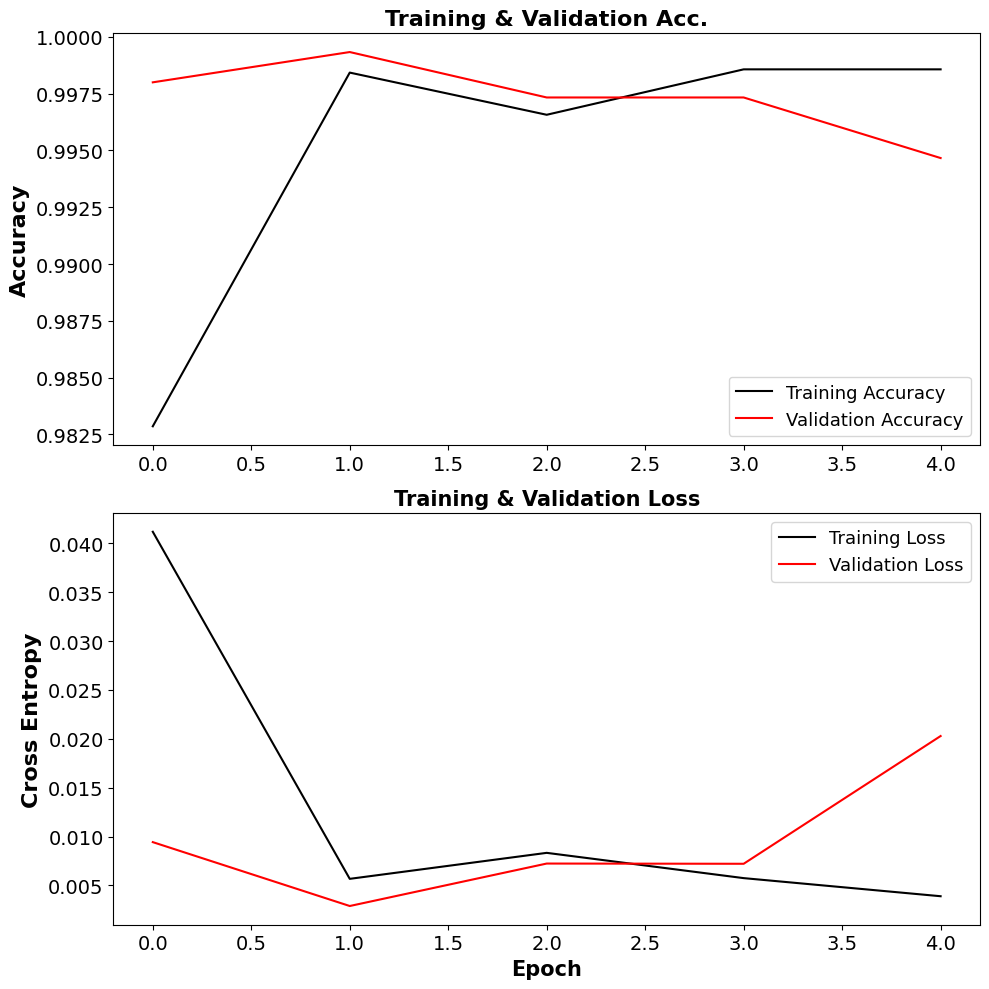

Saved: /content/exp-2-outputs/resnet50_training_curves.png


In [63]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)

plt.plot(acc, label='Training Accuracy', color='black')
plt.plot(val_acc, label='Validation Accuracy', color='red')


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='lower right', fontsize=13)
plt.ylabel('Accuracy', fontsize=16, weight='bold')
plt.title('Training & Validation Acc.', fontsize=16, weight='bold')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss', color='black')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right', fontsize=13)
plt.ylabel('Cross Entropy', fontsize=16, weight='bold')
plt.title('Training & Validation Loss', fontsize=15, weight='bold')
plt.xlabel('Epoch', fontsize=15, weight='bold')
plt.tight_layout()
TRAINING_CURVES_PATH = OUTPUT_DIR / 'resnet50_training_curves.png'
plt.savefig(TRAINING_CURVES_PATH, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', TRAINING_CURVES_PATH)


In [64]:
# Load the checkpoint selected only by validation loss.
best_model = keras.models.load_model(BEST_MODEL_PATH)
assert test_resnet.shuffle is False

test_resnet.reset()
test_metrics = best_model.evaluate(
    test_dataset, steps=len(test_resnet), return_dict=True, verbose=1
)

test_resnet.reset()
test_probabilities = best_model.predict(test_resnet, verbose=1).ravel()
y_true = np.asarray(test_resnet.classes, dtype=int)
y_pred = (test_probabilities >= 0.5).astype(int)

assert len(y_true) == len(test_df) == 1500
assert test_probabilities.shape == (1500,)
assert np.isfinite(test_probabilities).all()
assert ((test_probabilities >= 0.0) & (test_probabilities <= 1.0)).all()

target_names = ['benign', 'adenocarcinoma']
report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
print(classification_report(
    y_true, y_pred, target_names=target_names, digits=4, zero_division=0
))
print('Test metrics:', test_metrics)

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 313ms/step - accuracy: 0.9973 - loss: 0.0093 - precision: 0.9947 - recall: 1.0000 - roc_auc: 1.0000
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step
                precision    recall  f1-score   support

        benign     1.0000    0.9947    0.9973       750
adenocarcinoma     0.9947    1.0000    0.9973       750

      accuracy                         0.9973      1500
     macro avg     0.9973    0.9973    0.9973      1500
  weighted avg     0.9973    0.9973    0.9973      1500

Test metrics: {'accuracy': 0.9973333477973938, 'loss': 0.009272685274481773, 'precision': 0.9946949481964111, 'recall': 1.0, 'roc_auc': 0.9999865889549255}


In [65]:
def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, weight='bold', fontsize=16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=14)
    plt.yticks(tick_marks, classes, fontsize=14)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", fontsize=12, weight='bold',
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=16, weight='bold')
    plt.xlabel('Predicted label', fontsize=16, weight='bold')

Normalized confusion matrix


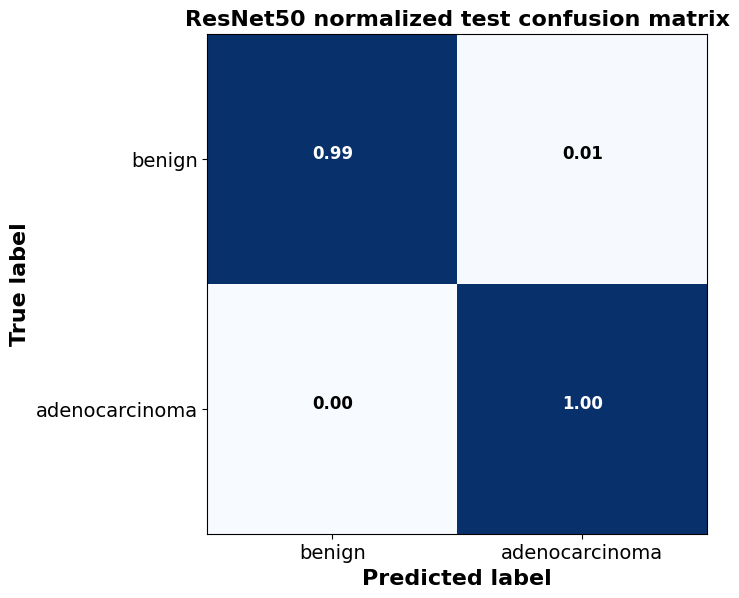

,benign,adenocarcinoma
benign,746,4
adenocarcinoma,0,750


In [66]:
cnf_matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
assert cnf_matrix.shape == (2, 2)
assert cnf_matrix.sum() == 1500

CONFUSION_MATRIX_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.csv'
CONFUSION_MATRIX_NORMALIZED_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix_normalized.csv'
CONFUSION_MATRIX_PLOT_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.png'

cm_frame = pd.DataFrame(cnf_matrix, index=target_names, columns=target_names)
cm_frame.to_csv(CONFUSION_MATRIX_PATH)
cm_normalized = cnf_matrix / cnf_matrix.sum(axis=1, keepdims=True)
pd.DataFrame(cm_normalized, index=target_names, columns=target_names).to_csv(
    CONFUSION_MATRIX_NORMALIZED_PATH
)

plt.figure(figsize=(7, 7))
plot_confusion_matrix(
    cnf_matrix,
    classes=target_names,
    normalize=True,
    title='ResNet50 normalized test confusion matrix',
)
plt.savefig(CONFUSION_MATRIX_PLOT_PATH, dpi=160, bbox_inches='tight')
plt.show()
display(cm_frame)

In [67]:
METRICS_PATH = OUTPUT_DIR / 'resnet50_test_metrics.json'
REPORT_PATH = OUTPUT_DIR / 'resnet50_classification_report.json'
PREDICTIONS_PATH = OUTPUT_DIR / 'resnet50_test_predictions.csv'

metrics_evidence = {key: float(value) for key, value in test_metrics.items()}
metrics_evidence.update({
    'decision_threshold': 0.5,
    'test_samples': int(len(y_true)),
    'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
    'best_validation_loss': float(np.min(history.history['val_loss'])),
})
METRICS_PATH.write_text(json.dumps(metrics_evidence, indent=2), encoding='utf-8')
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding='utf-8')

prediction_evidence = test_df[['relative_path', 'class_name', 'label']].copy()
prediction_evidence['adenocarcinoma_probability'] = test_probabilities
prediction_evidence['predicted_label'] = y_pred
prediction_evidence['predicted_class'] = np.where(
    y_pred == 1, 'adenocarcinoma', 'benign'
)
prediction_evidence.to_csv(PREDICTIONS_PATH, index=False)

for artifact_path in [METRICS_PATH, REPORT_PATH, PREDICTIONS_PATH,
                      CONFUSION_MATRIX_PATH, CONFUSION_MATRIX_NORMALIZED_PATH,
                      CONFUSION_MATRIX_PLOT_PATH, TRAINING_CURVES_PATH]:
    assert artifact_path.is_file(), artifact_path
    print('Saved:', artifact_path)

Saved: /content/exp-2-outputs/resnet50_test_metrics.json
Saved: /content/exp-2-outputs/resnet50_classification_report.json
Saved: /content/exp-2-outputs/resnet50_test_predictions.csv
Saved: /content/exp-2-outputs/resnet50_confusion_matrix.csv
Saved: /content/exp-2-outputs/resnet50_confusion_matrix_normalized.csv
Saved: /content/exp-2-outputs/resnet50_confusion_matrix.png
Saved: /content/exp-2-outputs/resnet50_training_curves.png


In [70]:
# Control: si la similitud alta se debe a hermanas y no a que todo H&E se parece,
# cada imagen de prueba debe tener un numero acotado de vecinos muy similares
# (unas 14: el 70% de las ~20 variantes que Augmentor genero por corte de origen),
# y no cientos.
similitud = firmas[idx_test] @ firmas[idx_train].T

for umbral in (0.999, 0.9995):
    vecinos = (similitud >= umbral).sum(axis=1)
    print(f"Vecinos con similitud >= {umbral}:")
    print(f"  mediana: {np.median(vecinos):.0f}   "
          f"media: {vecinos.mean():.1f}   "
          f"maximo: {vecinos.max()}")

# Comparacion: vecino mas cercano frente a la similitud tipica
print("\nSimilitud maxima (mediana):", f"{np.median(similitud.max(axis=1)):.5f}")
print("Similitud tipica (mediana):", f"{np.median(similitud):.5f}")

Vecinos con similitud >= 0.999:
  mediana: 2   media: 1.9   maximo: 9
Vecinos con similitud >= 0.9995:
  mediana: 0   media: 0.6   maximo: 9

Similitud maxima (mediana): 0.99943
Similitud tipica (mediana): 0.89116


In [71]:
for umbral in (0.99, 0.995):
    vecinos = (similitud >= umbral).sum(axis=1)
    print(f">= {umbral}: mediana {np.median(vecinos):.0f}, "
          f"media {vecinos.mean():.1f}, maximo {vecinos.max()}")

>= 0.99: mediana 20, media 40.4, maximo 337
>= 0.995: mediana 8, media 9.8, maximo 89


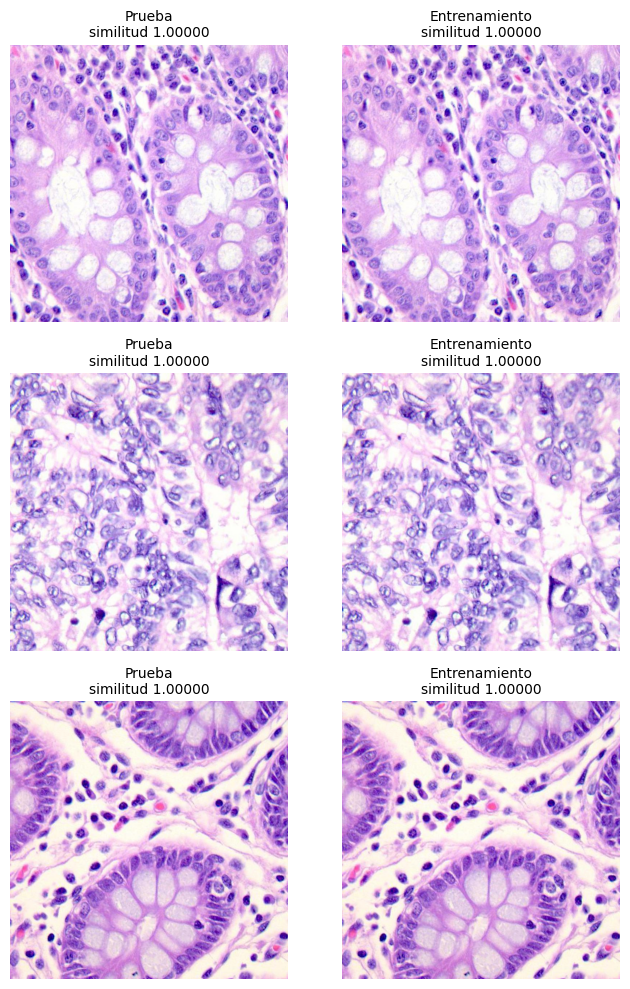

In [72]:
posicion_vecino = similitud.argmax(axis=1)
similitud_maxima = similitud.max(axis=1)
seleccion = np.argsort(-similitud_maxima)[:3]

figura, ejes = plt.subplots(3, 2, figsize=(7, 10))
for fila, i in enumerate(seleccion):
    for columna, (marco, ruta) in enumerate([
        ("Prueba", test_df["filepath"].iloc[i]),
        ("Entrenamiento", train_df["filepath"].iloc[posicion_vecino[i]]),
    ]):
        with Image.open(ruta) as archivo:
            ejes[fila, columna].imshow(archivo.convert("RGB"))
        ejes[fila, columna].set_title(
            f"{marco}\nsimilitud {similitud_maxima[i]:.5f}", fontsize=10
        )
        ejes[fila, columna].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pares_hermanas.png", dpi=160, bbox_inches="tight")
plt.show()

In [68]:
DEPLOY_MODEL_PATH = OUTPUT_DIR / 'resnet50_binary_deploy.keras'
best_model.save(DEPLOY_MODEL_PATH)
print('Modelo para despliegue:', DEPLOY_MODEL_PATH)